In [1]:
import torchio as tio 

In [2]:
# helper functions : 
import torchio as tio 
def plot(path):
    subject = tio.Subject(
        T1=tio.ScalarImage(path),
    )
    subject.plot(figsize=(15,5))

def plot_seg(path):
    subject = tio.Subject(
        seg=tio.LabelMap(path),
    )
    subject.plot(figsize=(15,5))


In [5]:
!mri_synthseg -h

usage: mri_synthseg [-h] [--i I] [--o O] [--parc] [--robust] [--fast] [--ct]
                    [--vol VOL] [--qc QC] [--post POST] [--resample RESAMPLE]
                    [--crop CROP [CROP ...]] [--threads THREADS] [--cpu]
                    [--v1] [--photo PHOTO]

SynthSeg

optional arguments:
  -h, --help            show this help message and exit
  --i I                 Image(s) to segment. Can be a path to an image or to a
                        folder.
  --o O                 Segmentation output(s). Must be a folder if --i
                        designates a folder.
  --parc                (optional) Whether to perform cortex parcellation.
  --robust              (optional) Whether to use robust predictions (slower).
  --fast                (optional) Bypass some processing for faster
                        prediction.
  --ct                  (optional) Clip CT scans in Hounsfield scale to [0,
                        80]
  --vol VOL             (optional) Output CSV file 

In [33]:
from_path ="/data1/syliu/ixi_mcx_2025/fix_synthseg_issues/pmcx_temp_data/m2m_20250614224327/T1.nii.gz"
simnibs_out_path ="/data1/syliu/ixi_mcx_2025/fix_synthseg_issues/temp_output/final_tissues_synthseg.nii.gz"
# !mri_synthseg --i $from_path --o $out_path


In [6]:
import pandas as pd
def from_csv_get_subject_coord(subject_csv, region_name):

    df = pd.read_csv(subject_csv, header=None)
    x, y, z = df[df[4] == region_name].values[0][1:4]
    return np.array([x, y, z])

In [49]:
# 2.pmcx.run.both
# This script runs the refactored MCX pipeline twice: once in simple mode and once in full mode.
# Outputs are saved to separate directories: ./results_run_simple and ./results_run_full.

import os
import subprocess
from pmcx_utils import run_stage1, run_stage2

# Optional: check GPU status
try:
    subprocess.run(["nvidia-smi"])  # non-fatal if not available
except Exception:
    pass

# Prepare temp data (idempotent)
os.makedirs("pmcx_temp_data", exist_ok=True)
subprocess.run([
    "cp", "-r",
    "/data1/syliu/work25_opensource_pre/m2m_20250614224327",
    "pmcx_temp_data/m2m_20250614224327"
], check=False)


def launch_simple_run_main(path):
    # Parameters
    DATA_ROOT = "pmcx_temp_data/m2m_20250614224327"
    subject_csv = os.path.join(DATA_ROOT, "eeg_positions", "EEG10-10_UI_Jurak_2007.csv")
    seg_path = None   # Provide for target mode if needed

    region_name = "Fp1"
    src_dir_mode = "default"  # one of ['default','fixed','target']

    # Power/time
    p = 250.0  # irradiance (mW)
    t = 8.0    # time (mins)
    # Optional source overrides
    srctype = None        # e.g., 'disk'
    srcparam1 = None      # e.g., [12,0,0,0]
    srcparam2 = None      # e.g., [0,0,0,0]

    # Check inputs
    for chk in [path, subject_csv]:
        if not os.path.exists(chk):
            raise FileNotFoundError(f"Path {chk} does not exist")
        else:
            print(f"Path {chk} exists")

    # Stage 1
    stage1_inputs = {
        'path': path,
        'subject_csv': subject_csv,
        'seg_path': seg_path,
        'region_name': region_name,
        'src_dir_mode': src_dir_mode,
    }
    stage1_out = run_stage1(stage1_inputs)
    print("Stage 1 completed.")

    # Build custom source if provided
    custom_src = None
    if srctype is not None:
        custom_src = {'srctype': srctype}
        if srcparam1 is not None:
            custom_src['srcparam1'] = srcparam1
        if srcparam2 is not None:
            custom_src['srcparam2'] = srcparam2

    # # Stage 2 - simple
    # simple_save = "./results_run_simple"
    # # if not os.path.exists(os.path.join(simple_save,"MCX_results_log.nii.gz")):
    # if True:
    #     print("Force to run again")
    #     stage2_simple = {
    #         'vol': stage1_out['vol'],
    #         'src_dir': stage1_out['src_dir'],
    #         'src_pos': stage1_out['src_pos'],
    #         'stage_2_mode': 'simple',
    #         'custom_src': custom_src,
    #         'save_path': simple_save,
    #         'p': p,
    #         't': t,
    #         'path': path,
    #     }
    #     print("Running Stage 2 (simple mode)...")
    #     stage2_out_simple = run_stage2(stage2_simple)
    #     print(f"Simple mode outputs saved to: {stage2_out_simple['output_path']}")
    # else:
    #     print(f"Simple mode outputs already exist in {simple_save}")

def launch_simple_run(path):
    try:
        launch_simple_run_main(path)
    except Exception as e:
        print(f"Error running simple mode for {path}: {e}")


Unable to determine the device handle for GPU0000:18:00.0: Unknown Error


Path /data1/syliu/ixi_mcx_2025/fix_synthseg_issues/pmcx_temp_data/m2m_20250614224327/final_tissues.nii.gz exists
Path pmcx_temp_data/m2m_20250614224327/eeg_positions/EEG10-10_UI_Jurak_2007.csv exists
{'path': '/data1/syliu/ixi_mcx_2025/fix_synthseg_issues/pmcx_temp_data/m2m_20250614224327/final_tissues.nii.gz', 'subject_csv': 'pmcx_temp_data/m2m_20250614224327/eeg_positions/EEG10-10_UI_Jurak_2007.csv', 'seg_path': None, 'region_name': 'Fp1', 'src_dir_mode': 'default'} [-32.06839193 119.42308444   6.19622117]
(4, 4)
numpy space [ 51.4845103  228.53822041 110.34423097] (172, 256, 256)
real spcae [ 51.4845103  214.25458163 103.44771653] (172, 240, 240) {0, 1, 2, 3, 5, 6, 7, 8, 9, 10}
using default mode, ignoring seg_path
tar_pos real space [ 64.06685484 185.91722803 113.50870786]


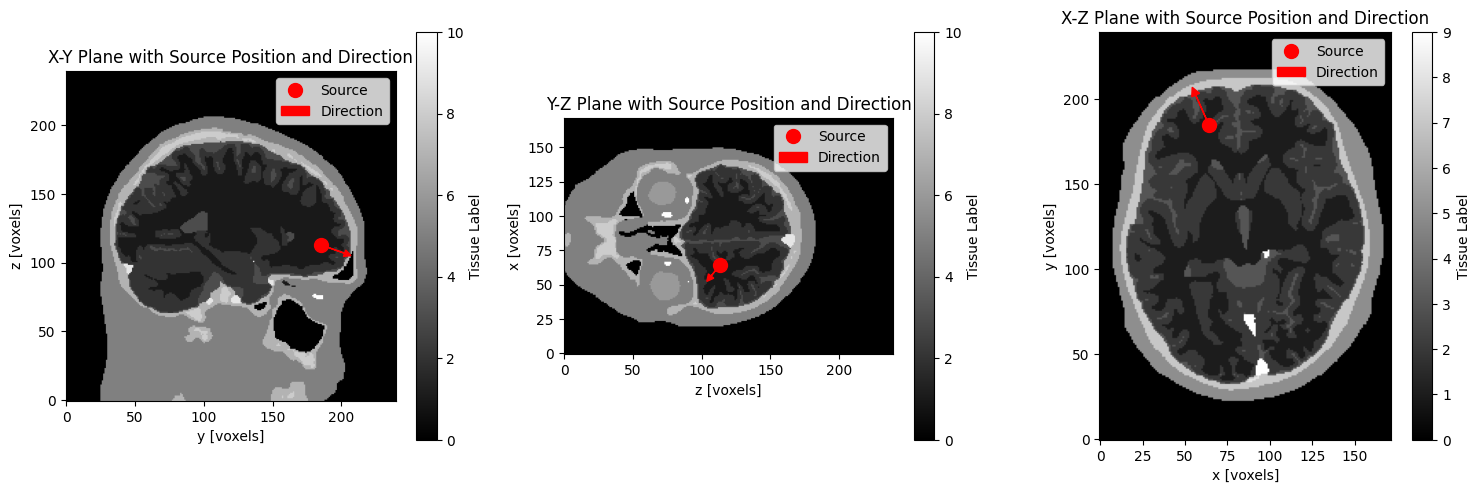

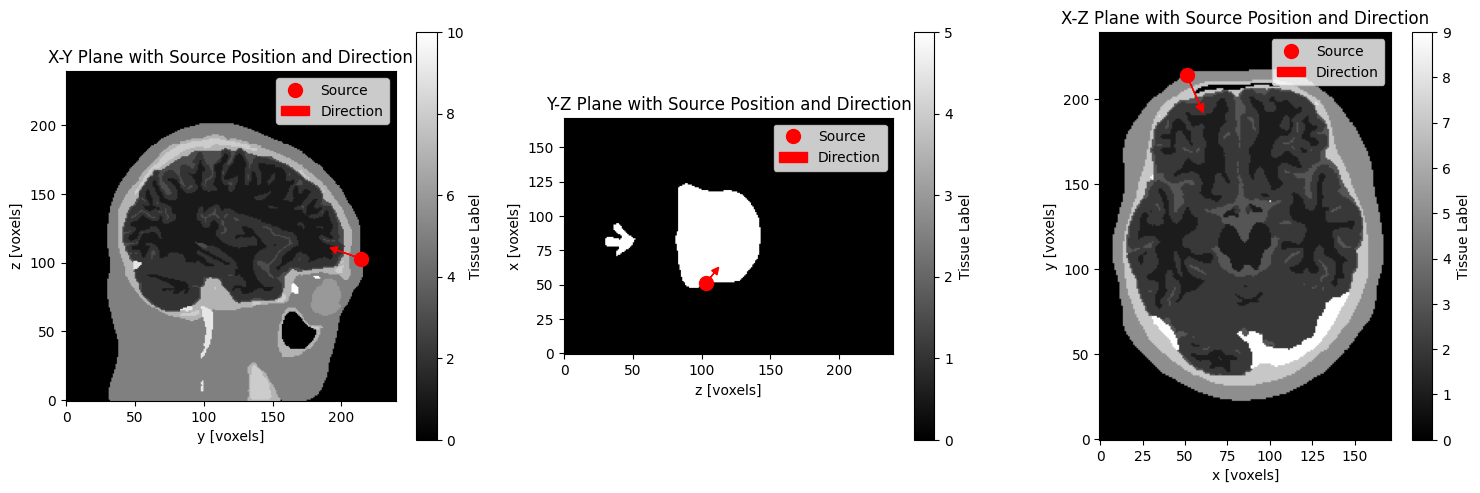

[ 51.4845103  214.25458163 103.44771653] [ 0.38600062 -0.8693321   0.30865065] (172, 240, 240)
Stage 1 completed.


In [50]:
final_tissues_path = "/data1/syliu/ixi_mcx_2025/fix_synthseg_issues/pmcx_temp_data/m2m_20250614224327/final_tissues.nii.gz"
launch_simple_run(final_tissues_path)

(172, 256, 256, 1)
dim [  4 172 256 256   1   1   1   1]
pixdim [1.     1.     0.9375 0.9375 1.     1.     1.     1.    ]
[[  1.           0.           0.         -83.55290222]
 [  0.           0.9375       0.         -94.83149719]
 [  0.           0.           0.9375     -97.25149536]
 [  0.           0.           0.           1.        ]]
(172, 240, 240)
dim [  3 172 240 240   1   1   1   1]
pixdim [1. 1. 1. 1. 1. 1. 1. 1.]
[[  1.           0.           0.         -83.55290222]
 [  0.           1.           0.         -94.80024719]
 [  0.           0.           1.         -97.22024536]
 [  0.           0.           0.           1.        ]]
Path /data1/syliu/ixi_mcx_2025/fix_synthseg_issues/temp_output/final_tissues_synthseg.nii.gz exists
Path pmcx_temp_data/m2m_20250614224327/eeg_positions/EEG10-10_UI_Jurak_2007.csv exists
{'path': '/data1/syliu/ixi_mcx_2025/fix_synthseg_issues/temp_output/final_tissues_synthseg.nii.gz', 'subject_csv': 'pmcx_temp_data/m2m_20250614224327/eeg_position

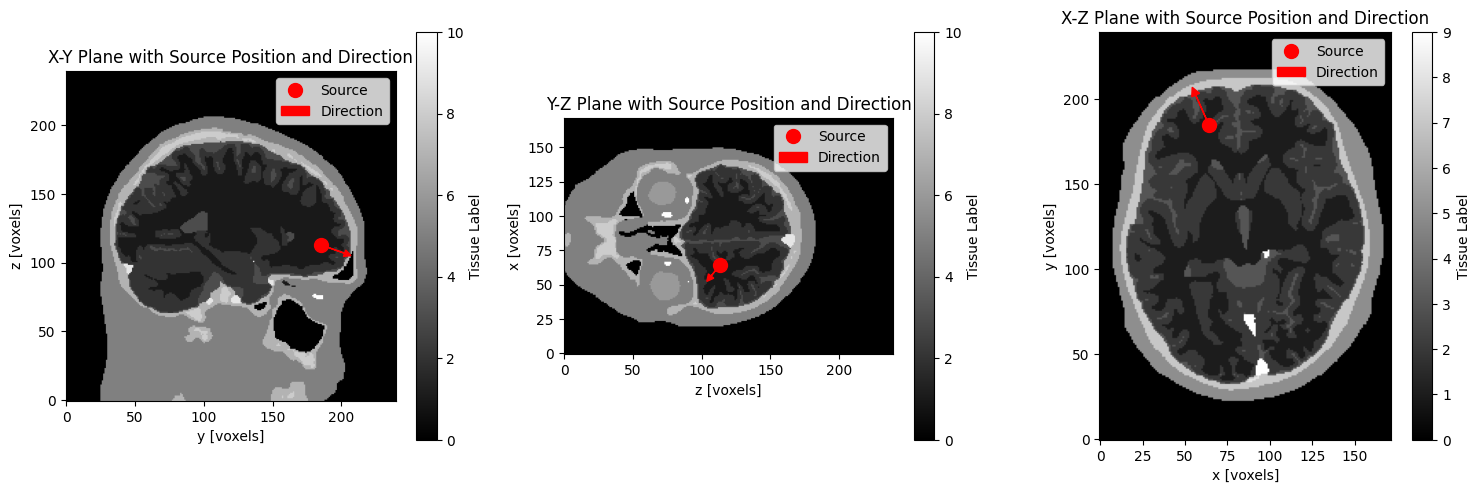

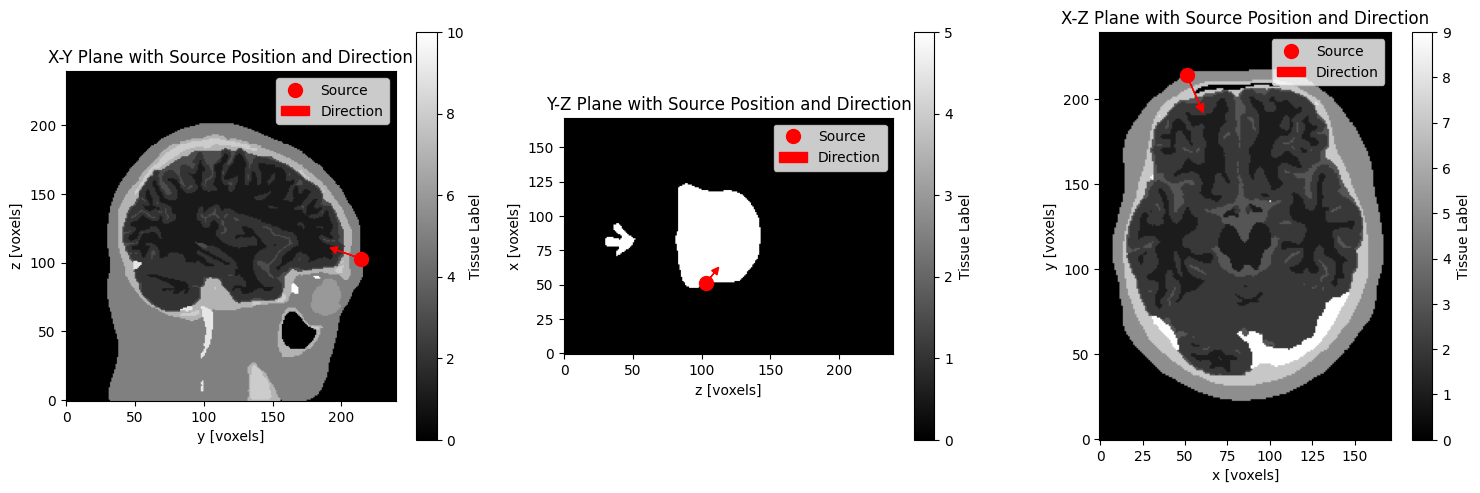

[ 51.4845103  214.25458163 103.44771653] [ 0.38600062 -0.8693321   0.30865065] (172, 240, 240)
Stage 1 completed.
Path /data1/syliu/ixi_mcx_2025/fix_synthseg_issues/temp_output/final_tissues_synthseg_4d.nii.gz exists
Path pmcx_temp_data/m2m_20250614224327/eeg_positions/EEG10-10_UI_Jurak_2007.csv exists
{'path': '/data1/syliu/ixi_mcx_2025/fix_synthseg_issues/temp_output/final_tissues_synthseg_4d.nii.gz', 'subject_csv': 'pmcx_temp_data/m2m_20250614224327/eeg_positions/EEG10-10_UI_Jurak_2007.csv', 'seg_path': None, 'region_name': 'Fp1', 'src_dir_mode': 'default'} [-32.06839193 119.42308444   6.19622117]
(4, 4)
numpy space [ 51.4845103  214.22333163 103.41646653] (172, 240, 240)
real spcae [ 51.4845103  214.22333163 103.41646653] (172, 240, 240) {0, 2, 3, 4, 5, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 24, 26, 28, 41, 42, 43, 44, 46, 47, 49, 50, 51, 52, 53, 54, 58, 60}
using default mode, ignoring seg_path
tar_pos real space [ 60.28492813 185.78833676 113.25831622]


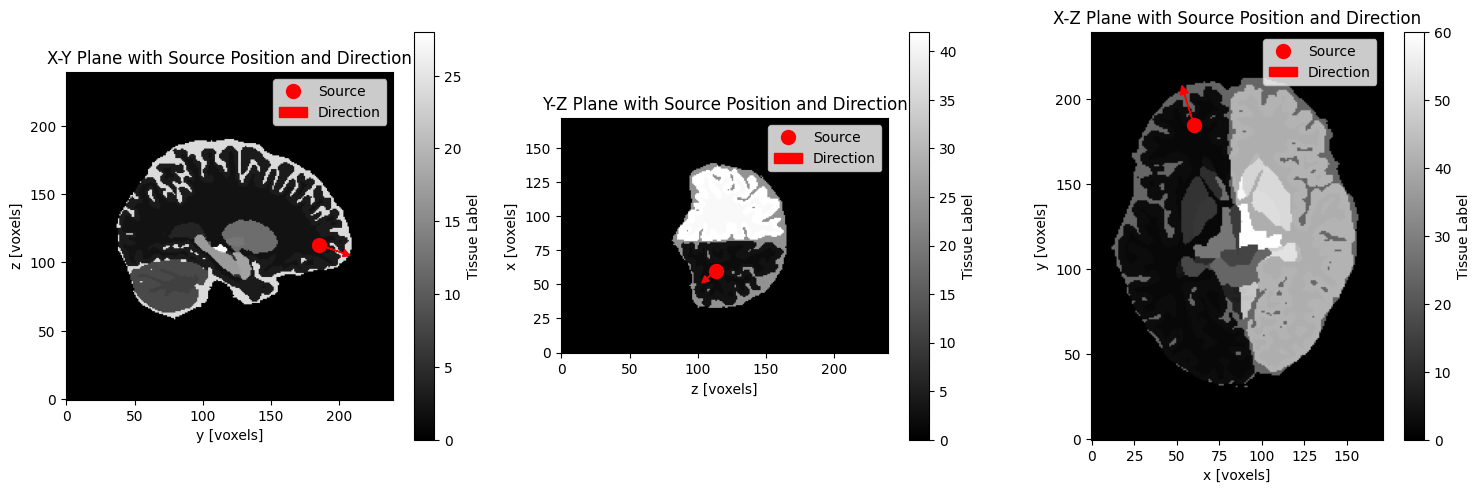

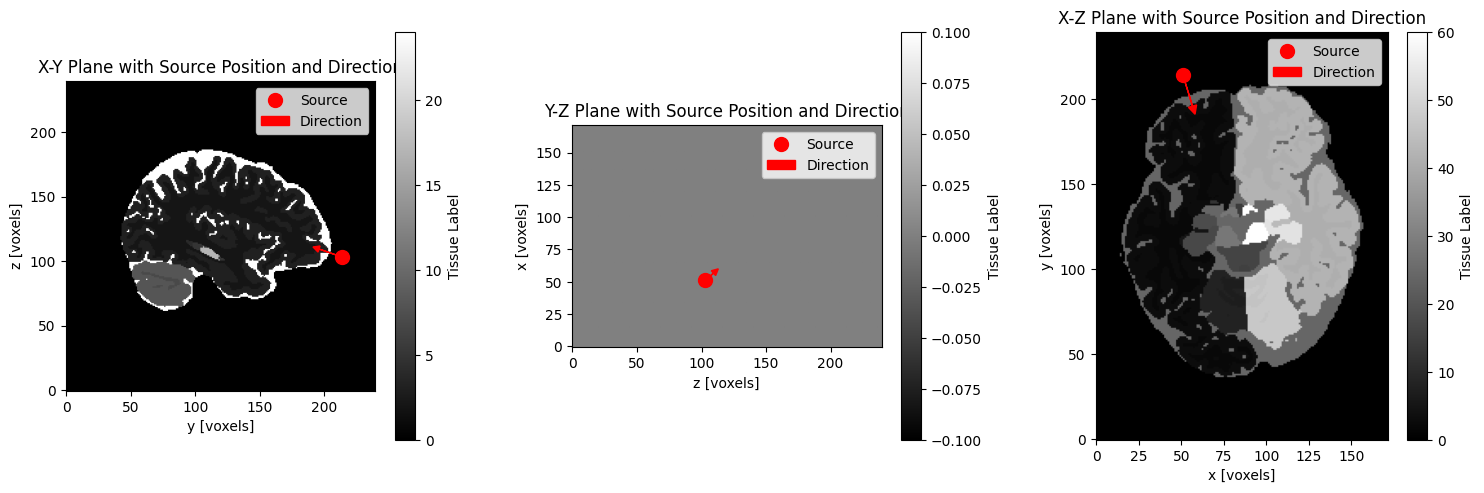

[ 51.4845103  214.22333163 103.41646653] [ 0.28070997 -0.90700086  0.31392888] (172, 240, 240)
Stage 1 completed.


In [51]:

import nibabel as nib
# check affine and origin !! 
def check(path):
    img = nib.load(path)
    print(img.get_fdata().shape)
    header = img.header
    important_keys=["dim","pixdim"]
    for key in important_keys:
        print(key,header[key])
    print(img.affine)
check(final_tissues_path)
check(simnibs_out_path)

launch_simple_run(simnibs_out_path)
# convert 3d simnibs output to 4d 
simnibs_out_path_4d = simnibs_out_path.replace(".nii","_4d.nii")
simnibs_img = nib.load(simnibs_out_path)
simnibs_img_4d = nib.Nifti1Image(simnibs_img.get_fdata()[...,None], simnibs_img.affine)
nib.save(simnibs_img_4d, simnibs_out_path_4d)

check(simnibs_out_path_4d)
launch_simple_run(final_tissues_path)
launch_simple_run(simnibs_out_path_4d)

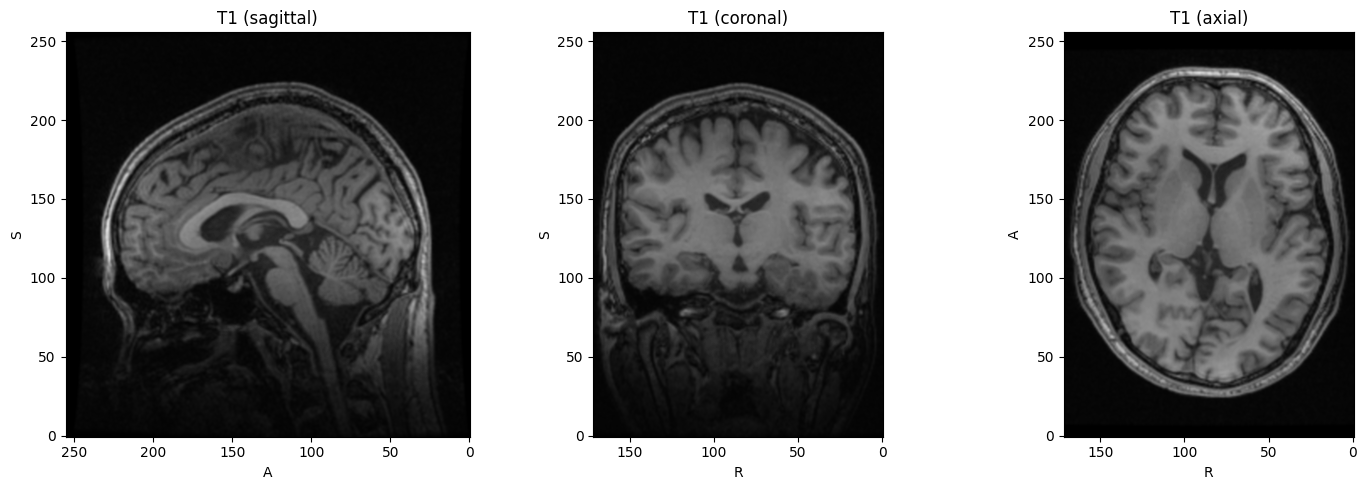

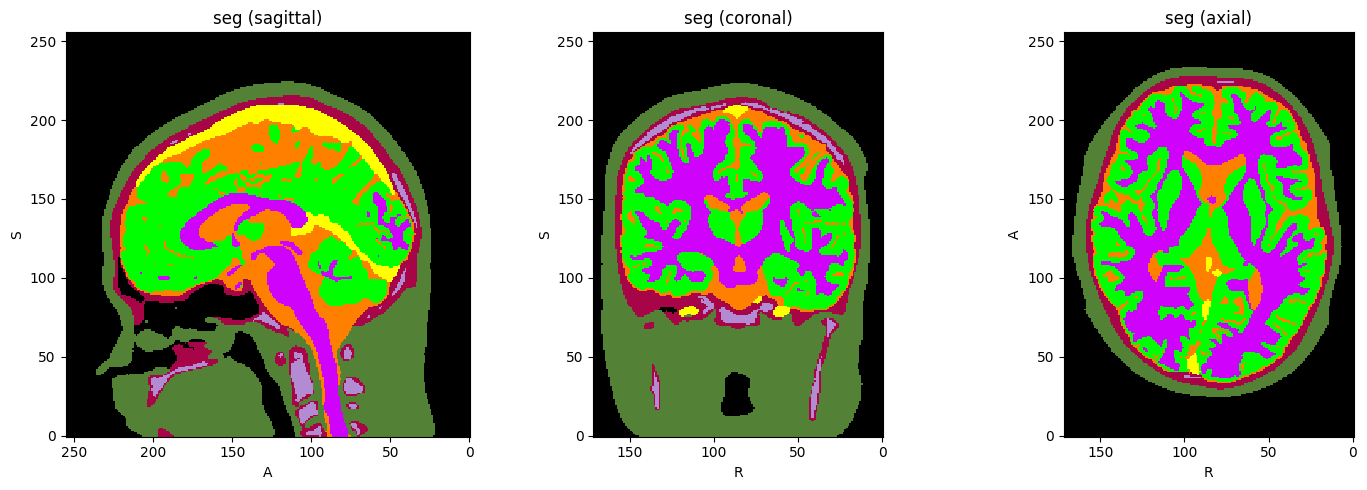

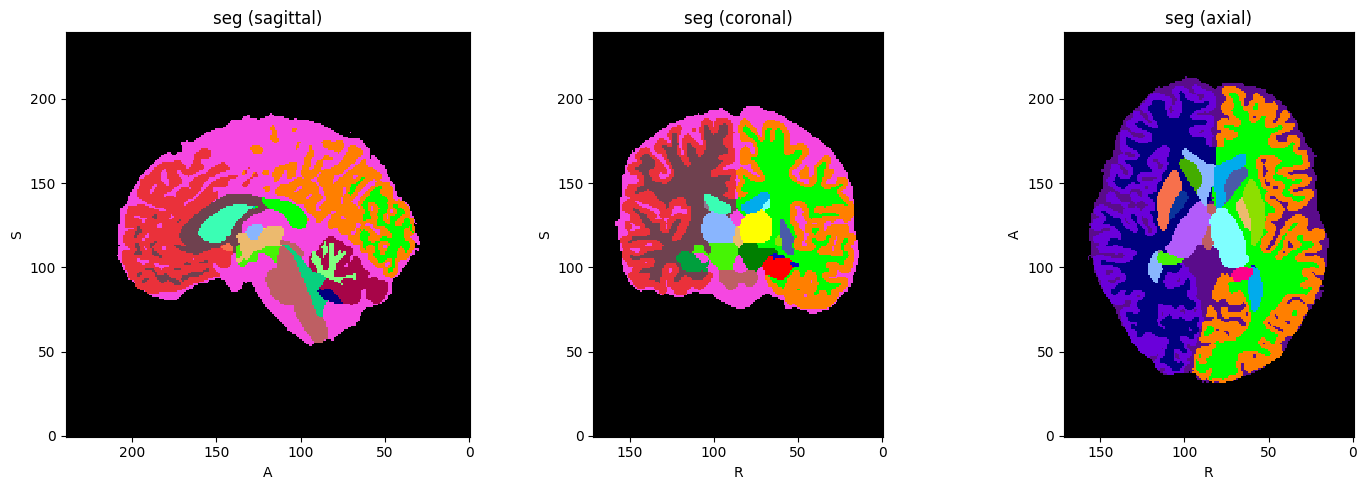

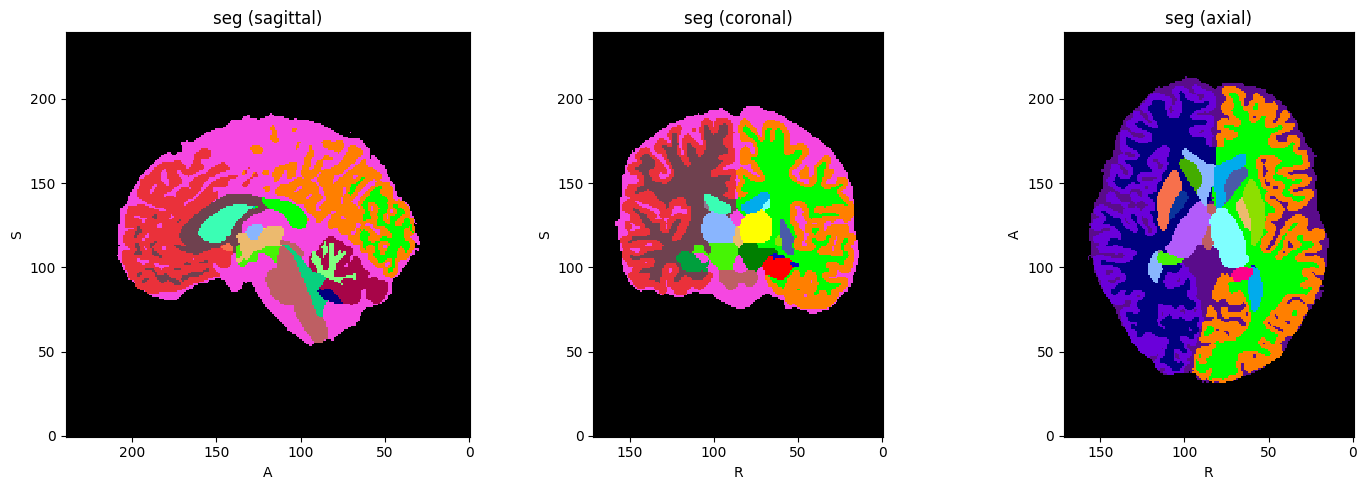

In [56]:
plot(raw_T1)
plot_seg(final_tissues_path)
plot_seg(simnibs_out_path)
plot_seg(simnibs_out_path_4d)



# Visual check codes

In [1]:
import ants 

In [2]:
from_path ="/data1/syliu/ixi_mcx_2025/fix_synthseg_issues/pmcx_temp_data/m2m_20250614224327/T1.nii.gz"
simnibs_out_path ="/data1/syliu/ixi_mcx_2025/fix_synthseg_issues/temp_output/final_tissues_synthseg.nii.gz"
# !mri_synthseg --i $from_path --o $out_path
final_tissues_path = "/data1/syliu/ixi_mcx_2025/fix_synthseg_issues/pmcx_temp_data/m2m_20250614224327/final_tissues.nii.gz"
# launch_simple_run(final_tissues_path)

simnibs_out_path_4d = simnibs_out_path.replace(".nii","_4d.nii")

In [ ]:
import matplotlib.pyplot as plt 
import nibabel as nib 
data ={
    "T1":from_path,
    "synthseg":final_tissues_path,
}

data ={k:nib.load(v).get_fdata() for k,v in data.items()}

np_slice = [51.4845103,228.53822041,110.34423097]
np_slice = [int(slices) for slices in np_slice]
np_slice
yz_plan = data["T1"][np_slice[0],:,:]
xz_plan = data["T1"][:,np_slice[1],:]
xy_plan = data["T1"][:,:,np_slice[2]]
# sub plots : 

plt.imshow()

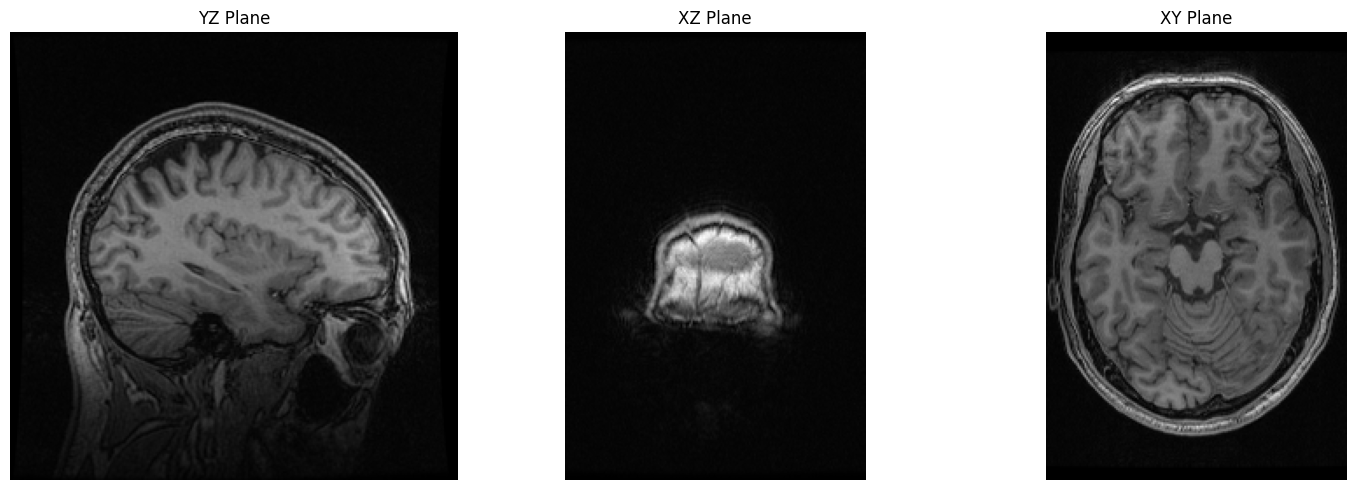

In [11]:
import matplotlib.pyplot as plt 
import nibabel as nib 
import numpy as np

data ={
    "T1":from_path,
    "synthseg":final_tissues_path,
}

data ={k:nib.load(v).get_fdata() for k,v in data.items()}

np_slice = [51.4845103,228.53822041,110.34423097]
np_slice = [int(slices) for slices in np_slice]

yz_plan = data["T1"][np_slice[0],:,:]
xz_plan = data["T1"][:,np_slice[1],:]
xy_plan = data["T1"][:,:,np_slice[2]]

# sub plots : 
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(yz_plan.T, cmap='gray', origin='lower')
axes[0].set_title('YZ Plane')
axes[0].axis('off')

axes[1].imshow(xz_plan.T, cmap='gray', origin='lower')
axes[1].set_title('XZ Plane')
axes[1].axis('off')

axes[2].imshow(xy_plan.T, cmap='gray', origin='lower')
axes[2].set_title('XY Plane')
axes[2].axis('off')

plt.tight_layout()
plt.show()